In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from m2fgb.m2fgb import M2FGBClassifier
from data import get_strat_split
%load_ext autoreload
%autoreload 2

## Downloading ACSIncome dataset

In [ ]:
# download dataset from google drive
import gdown
import zipfile
import os

url = "https://drive.google.com/file/d/1Uee2Mvmm8cmY8iiOA4b4nxxDakeEm61-/view?usp=sharing"
output = "../data.zip"
gdown.download(url, output, quiet=False, fuzzy=True)


with zipfile.ZipFile(output, 'r') as zip_ref:
    zip_ref.extractall("../")

# remove the downloaded zip file
os.remove(output)

In [3]:
(
    X_train,
    A_train,
    Y_train,
    X_val,
    A_val,
    Y_val,
    X_test,
    A_test,
    Y_test,
) = get_strat_split(dataset="acsincome", n_groups=8, random_state=0)

{'Female, African-American': 0, 'Male, White': 1, 'Female, White': 2, 'Male, African-American': 3, 'Male, Other': 4, 'Male, Asian': 5, 'Female, Other': 6, 'Female, Asian': 7}


In [18]:
model_fair = M2FGBClassifier(
    n_estimators=100,
    fairness_constraint="true_positive_rate",
    max_depth=5,
    random_state=0,
    fair_weight=0.75,
)
model_fair.fit(X_train, Y_train, A_train)

model_base = M2FGBClassifier(
    n_estimators=100,
    fairness_constraint="true_positive_rate",
    max_depth=5,
    random_state=0,
    fair_weight=0.0,
)
model_base.fit(X_train, Y_train, A_train);


In [19]:
def plot_loss_decay(model, ax):
    loss = np.concatenate([[row["loss"]] for row in model.info])

    max_loss = np.max(loss[-1, :])
    for i in range(loss.shape[1]):
        ax.plot(loss[:, i], label=f"Loss {i+1}")
    ax.annotate(
        f"{max_loss:.4f}",
        xy=(len(loss) - 1, max_loss),
        textcoords="offset points",
        xytext=(0, 10),
        ha="center",
    )
    ax.set_xlabel("Iteration")
    ax.set_ylabel("Loss")
    ax.set_title("Loss Decay Over Iterations")
    ax.legend()
    ax.grid(True)

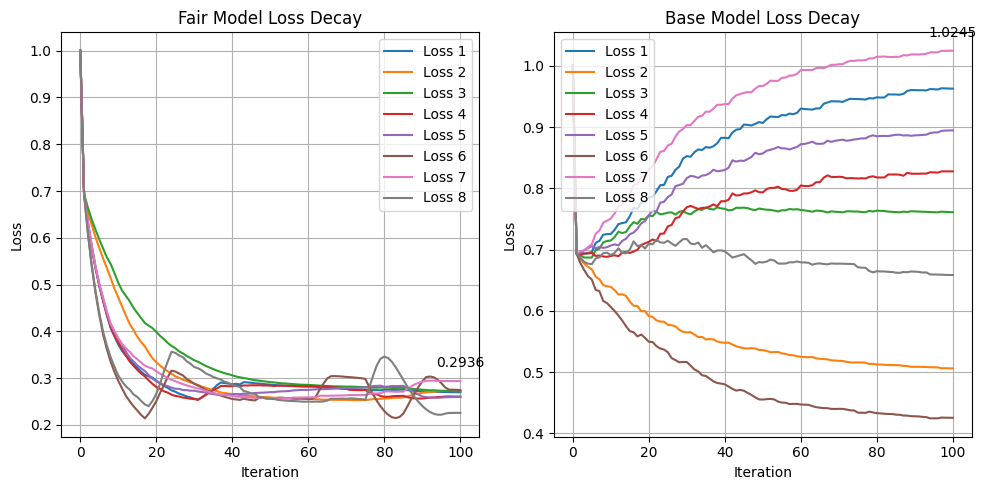

In [20]:
fig, axs = plt.subplots(1, 2, figsize=(10, 5))
plot_loss_decay(model_fair, axs[0])
axs[0].set_title("Fair Model Loss Decay")
plot_loss_decay(model_base, axs[1])
axs[1].set_title("Base Model Loss Decay")
plt.tight_layout()
plt.show()